# Определение тональности отзывов на банки с помощью LSTM в PyTorch

Создаем нейронную сеть с рекуррентным слоем и обучаем ее определять тональность отзывов на банки:
положительный отзыв или отрицательный.

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".

Мы используем библиотеку **PyTorch**. Описание моделей SimpleRNN, LSTM и GRU, а также то, зачем
каждый из этих блоков появился в нейронных сетях, — в ноутбуке
[`rnn_architectures_theory.ipynb`](rnn_architectures_theory.ipynb).

In [1]:
pip install pymorphy3[fast]

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import pymorphy3
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from collections import Counter
from pathlib import Path
import urllib.request
import matplotlib.pyplot as plt
%matplotlib inline

random_state = 42
np.random.seed(random_state)
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| устройство:', device)

PyTorch 2.1.2+cu121 | устройство: cuda


In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /home/reshetnikov/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/reshetnikov/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/reshetnikov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

True

## Константы

In [51]:
max_words = 10000
maxlen = 200
random_state = 42
batch_size = 128
epochs = 15

## Загружаем и готовим набор данных

In [52]:
data_path = 'data'
path = Path(data_path)

if not path.exists():
    path.mkdir(parents=True, exist_ok=True)

In [53]:
file_name = path / 'banks.csv'

if not file_name.exists():
    print('Загружаем banks.csv...')
    urllib.request.urlretrieve('https://www.dropbox.com/scl/fi/mhiwx4plaua183bnuqt5e/train2.csv?rlkey=wv4dalbsutmzu5br9qv5ez21v&dl=1', file_name)
else:
    print('banks.csv уже есть на месте')

banks.csv уже есть на месте


In [54]:
banks = pd.read_csv('data/banks.csv', index_col='id');

In [55]:
banks

,text,label
id,,
0,В Альфа-Банке работает замечательная девушка -...,1
1,Оформляя рассрочку в м. Видео в меге тёплый ст...,0
2,Очень порадовала оперативность работы в банке....,1
3,Имела неосторожность оформить потреб. кредит в...,0
4,Небольшая предыстория: Нашел на сайте MDM банк...,0
...,...,...
13994,"О высокой надёжности МКБ, порядочности и добро...",1
13995,"Обслуживаюсь в офисе на Чернореченской 42а, ка...",1
13996,Попала сегодня в очень неприятную ситуацию. Ре...,1


### Предобработка текста

Приводим текст к нижнему регистру, разбиваем на слова (токены), убираем знаки препинания,
приводим слова к начальной форме (лемматизация) и удаляем стоп-слова (союзы, предлоги, частицы).
На выходе получаем список нормальных форм слов.

In [56]:
def preprocess(text, stop_words, punctuation_marks, morph):
    tokens = word_tokenize(text.lower())
    preprocessed_text = []
    for token in tokens:
        if token not in punctuation_marks:
            lemma = morph.parse(token)[0].normal_form
            if lemma not in stop_words:
                preprocessed_text.append(lemma)
    return preprocessed_text

In [57]:
punctuation_marks = ['!', ',', '(', ')', ':', '-', '?', '.', '..', '...', '«', '»', ';', '–', '--']
stop_words = stopwords.words("russian")
morph = pymorphy3.MorphAnalyzer()

In [58]:
banks['Preprocessed_texts'] = banks.apply(lambda row: preprocess(row['text'], stop_words, punctuation_marks, morph), axis=1)

In [59]:
banks

,text,label,Preprocessed_texts
id,,,
0,В Альфа-Банке работает замечательная девушка -...,1,"[альфа-банк, работать, замечательный, девушка,..."
1,Оформляя рассрочку в м. Видео в меге тёплый ст...,0,"[оформлять, рассрочка, м., видео, мег, тёплый,..."
2,Очень порадовала оперативность работы в банке....,1,"[очень, порадовать, оперативность, работа, бан..."
3,Имела неосторожность оформить потреб. кредит в...,0,"[иметь, неосторожность, оформить, потреба, кре..."
4,Небольшая предыстория: Нашел на сайте MDM банк...,0,"[небольшой, предыстория, найти, сайт, mdm, бан..."
...,...,...,...
13994,"О высокой надёжности МКБ, порядочности и добро...",1,"[высокий, надёжность, мкб, порядочность, добро..."
13995,"Обслуживаюсь в офисе на Чернореченской 42а, ка...",1,"[обслуживаться, офис, чернореченский, 42а, физ..."
13996,Попала сегодня в очень неприятную ситуацию. Ре...,1,"[попасть, сегодня, очень, неприятный, ситуация..."


## Считаем частоту слов во всех отзывах

In [60]:
words = Counter()

In [61]:
for txt in banks['Preprocessed_texts']:
    words.update(txt)

In [62]:
words.most_common(20)

[('банк', 58189),
 ('карта', 30560),
 ('это', 28660),
 ('всё', 20599),
 ('день', 15729),
 ('сотрудник', 14527),
 ('который', 14519),
 ('кредит', 14490),
 ('деньга', 13701),
 ('счёт', 13681),
 ('отделение', 13414),
 ('клиент', 12681),
 ('мочь', 11140),
 ('свой', 11128),
 ('год', 10378),
 ('сказать', 9990),
 ('вопрос', 9638),
 ('ещё', 9606),
 ('очень', 9226),
 ('весь', 9004)]

## Создаем словарь, упорядоченный по частоте

В словаре будем использовать 2 специальных кода:
- Код заполнитель: 0
- Неизвестное слово: 1

Нумерация слов в словаре начинается с 2.

In [63]:
# Словарь, отображающий слова в коды
word_to_index = dict()
# Словарь, отображающий коды в слова
index_to_word = dict()

In [64]:
for i, word in enumerate(words.most_common(max_words - 2)):
    word_to_index[word[0]] = i + 2
    index_to_word[i + 2] = word[0]

In [65]:
list(word_to_index.items())[:5]

[('банк', 2), ('карта', 3), ('это', 4), ('всё', 5), ('день', 6)]

## Функция для преобразования списка слов в список кодов

In [66]:
def text_to_sequence(txt, word_to_index):
    seq = []
    for word in txt:
        index = word_to_index.get(word, 1)  # 1 означает неизвестное слово
        # Неизвестные слова не добавляем в выходную последовательность
        if index != 1:
            seq.append(index)
    return seq

In [67]:
banks['Sequences'] = banks.apply(lambda row: text_to_sequence(row['Preprocessed_texts'], word_to_index), axis=1)

In [68]:
banks

,text,label,Preprocessed_texts,Sequences
id,,,,
0,В Альфа-Банке работает замечательная девушка -...,1,"[альфа-банк, работать, замечательный, девушка,...","[61, 44, 896, 76, 194, 1842, 344, 2685, 396, 1..."
1,Оформляя рассрочку в м. Видео в меге тёплый ст...,0,"[оформлять, рассрочка, м., видео, мег, тёплый,...","[254, 836, 1155, 3189, 3865, 2956, 7316, 163, ..."
2,Очень порадовала оперативность работы в банке....,1,"[очень, порадовать, оперативность, работа, бан...","[20, 1033, 890, 30, 2, 461, 175, 3, 613, 1743,..."
3,Имела неосторожность оформить потреб. кредит в...,0,"[иметь, неосторожность, оформить, потреба, кре...","[113, 4790, 70, 2343, 9, 61, 20, 2639, 1264, 3..."
4,Небольшая предыстория: Нашел на сайте MDM банк...,0,"[небольшой, предыстория, найти, сайт, mdm, бан...","[405, 3824, 262, 85, 2, 633, 3, 4866, 2, 283, ..."
...,...,...,...,...
13994,"О высокой надёжности МКБ, порядочности и добро...",1,"[высокий, надёжность, мкб, порядочность, добро...","[388, 2296, 792, 5000, 8128, 7, 3073, 120, 427..."
13995,"Обслуживаюсь в офисе на Чернореченской 42а, ка...",1,"[обслуживаться, офис, чернореченский, 42а, физ...","[349, 26, 9465, 2126, 191, 16, 26, 134, 64, 11..."
13996,Попала сегодня в очень неприятную ситуацию. Ре...,1,"[попасть, сегодня, очень, неприятный, ситуация...","[502, 104, 20, 971, 53, 39, 213, 221, 3, 47, 3..."


## Готовим данные для обучения

### Выделяем данные для обучения и тестирования

In [69]:
train, test = train_test_split(banks, test_size=0.2)

In [70]:
train

,text,label,Preprocessed_texts,Sequences
id,,,,
10389,"Главное подать заявку, а успели они или нет и ...",0,"[главное, подать, заявка, успеть, нужно, это, ...","[553, 283, 62, 647, 93, 4, 2, 925, 889, 397, 7..."
11850,"К банку присматривался, чуть ли не несколько л...",1,"[банк, присматриваться, несколько, год, всё, р...","[2, 5677, 80, 16, 5, 814, 115, 48, 80, 2, 1194..."
9683,Более года являюсь клиентом ПАО АКБ «АВАНГАРД»...,1,"[год, являться, клиент, пао, акб, авангард, от...","[16, 84, 13, 1298, 3282, 249, 1313, 2, 656, 10..."
1311,Для конвертации валюты отправил деньги в Альфа...,0,"[конвертация, валюта, отправить, деньга, альфа...","[1131, 489, 195, 10, 8569, 23, 334, 20, 95, 10..."
664,"Фух... ну есть же банки, с которыми с первых м...",1,"[фух, банк, который, первый, минута, легко, ра...","[2, 8, 66, 56, 1173, 44, 3752, 219, 5, 2, 8, 7..."
...,...,...,...,...
863,Я в автосалоне Kia на Дубровке приобрела машин...,0,"[автосалон, kia, дубровка, приобрести, машина,...","[1200, 1151, 579, 9, 29, 1000, 1572, 420, 543,..."
11446,24.12.2016 моя пожилая мама Г***а Светлана Сер...,1,"[24.12.2016, пожилой, мама, г, *, *, *, светла...","[2932, 817, 1239, 111, 111, 111, 1319, 1921, 4..."
12582,"31 января 2011 года я, во время визита в офис ...",1,"[31, январь, 2011, год, время, визит, офис, ба...","[1572, 421, 1126, 16, 22, 726, 26, 2, 2969, 22..."


In [71]:
test

,text,label,Preprocessed_texts,Sequences
id,,,,
6588,"Пользуюсь картой ALLAIRLINES порядка 3 лет, ко...",1,"[пользоваться, карта, allairlines, порядок, 3,...","[75, 3, 361, 117, 16, 3444, 1132, 2277, 707, 9..."
9420,Нередко посещаю именно это отделение МКБ. Заме...,1,"[нередко, посещать, именно, это, отделение, мк...","[1435, 164, 4, 12, 792, 661, 321, 21, 22, 723,..."
1972,"Надеюсь, дальнейший опыт общения с банком буде...",1,"[надеяться, дальнейший, опыт, общение, банк, п...","[268, 504, 435, 296, 2, 1517, 1316, 152, 1622,..."
2889,Доброго часа.14 марта 2013 года у меня была по...,0,"[добрый, часа.14, март, 2013, год, похитить, м...","[173, 308, 777, 16, 5017, 579, 5178, 36, 243, ..."
12127,"Оставлю и я свой отзыв, с надеждой, что руково...",0,"[оставить, свой, отзыв, надежда, руководство, ...","[197, 15, 90, 974, 434, 2, 7948, 15, 13, 399, ..."
...,...,...,...,...
7298,Дернул меня Лукавый взять потреб кредит под фо...,0,"[дёрнуть, лукавый, взять, потреба, кредит, фот...","[5795, 121, 2343, 9, 4920, 4, 2, 1515, 81, 22,..."
6362,19 мая 2016 года муж пополнил кредитную карту ...,0,"[19, май, 2016, год, муж, пополнить, кредитный...","[1042, 420, 543, 16, 635, 800, 24, 3, 3773, 4,..."
1386,12 апреля открыл вклад Стратегия накопления в ...,1,"[12, апрель, открыть, вклад, стратегия, накопл...","[694, 397, 115, 48, 5497, 2786, 12, 2625, 8370..."


### Разделяем метки классов и данные для обучения

In [72]:
x_train_seq = train['Sequences']
y_train = train['label']

In [73]:
x_train_seq

id
10389    [553, 283, 62, 647, 93, 4, 2, 925, 889, 397, 7...
11850    [2, 5677, 80, 16, 5, 814, 115, 48, 80, 2, 1194...
9683     [16, 84, 13, 1298, 3282, 249, 1313, 2, 656, 10...
1311     [1131, 489, 195, 10, 8569, 23, 334, 20, 95, 10...
664      [2, 8, 66, 56, 1173, 44, 3752, 219, 5, 2, 8, 7...
                               ...                        
863      [1200, 1151, 579, 9, 29, 1000, 1572, 420, 543,...
11446    [2932, 817, 1239, 111, 111, 111, 1319, 1921, 4...
12582    [1572, 421, 1126, 16, 22, 726, 26, 2, 2969, 22...
871      [510, 61, 854, 7755, 390, 313, 188, 60, 1712, ...
9404     [173, 6, 181, 5372, 2, 8, 1397, 4993, 384, 39,...
Name: Sequences, Length: 11199, dtype: object

In [74]:
y_train

id
10389    0
11850    1
9683     1
1311     0
664      1
        ..
863      0
11446    1
12582    1
871      0
9404     1
Name: label, Length: 11199, dtype: int64

In [75]:
x_test_seq = test['Sequences']
y_test = test['label']

In [76]:
x_test_seq

id
6588     [75, 3, 361, 117, 16, 3444, 1132, 2277, 707, 9...
9420     [1435, 164, 4, 12, 792, 661, 321, 21, 22, 723,...
1972     [268, 504, 435, 296, 2, 1517, 1316, 152, 1622,...
2889     [173, 308, 777, 16, 5017, 579, 5178, 36, 243, ...
12127    [197, 15, 90, 974, 434, 2, 7948, 15, 13, 399, ...
                               ...                        
7298     [5795, 121, 2343, 9, 4920, 4, 2, 1515, 81, 22,...
6362     [1042, 420, 543, 16, 635, 800, 24, 3, 3773, 4,...
1386     [694, 397, 115, 48, 5497, 2786, 12, 2625, 8370...
4745     [72, 152, 9, 1676, 9, 1590, 2, 25, 1518, 663, ...
1056     [518, 2586, 27, 100, 1652, 2448, 109, 5198, 90...
Name: Sequences, Length: 2800, dtype: object

In [77]:
y_test

id
6588     1
9420     1
1972     1
2889     0
12127    0
        ..
7298     0
6362     0
1386     1
4745     0
1056     1
Name: label, Length: 2800, dtype: int64

## Дополняем отзывы до одинаковой длины

Отзывы имеют разную длину, а нейронная сеть принимает на вход последовательности одинаковой длины.
Дополняем короткие последовательности нулями (код заполнителя 0) до длины `maxlen` — это паддинг
*post*, нули добавляются в конец последовательности. Слишком длинные последовательности обрезаем.

In [78]:
def pad_sequences_post(sequences, maxlen):
    padded = np.zeros((len(sequences), maxlen), dtype=np.int64)
    for i, seq in enumerate(sequences):
        seq = np.asarray(seq, dtype=np.int64)[:maxlen]
        padded[i, :len(seq)] = seq
    return padded

In [79]:
x_train = torch.from_numpy(pad_sequences_post(x_train_seq, maxlen))
x_test = torch.from_numpy(pad_sequences_post(x_test_seq, maxlen))
y_train = torch.from_numpy(y_train.to_numpy().astype(np.float32))
y_test = torch.from_numpy(y_test.to_numpy().astype(np.float32))

In [80]:
x_train[:5]

tensor([[ 553,  283,   62,  647,   93,    4,    2,  925,  889,  397,  757,   24,
          252,   30,   62,  432,    9,   61,    2,  276,  431,   62, 2709,    6,
         1358,  397,   62,  414,    2,   14,  401, 2437,  161,  222,   62,  128,
          530,  431, 1346,  420,  357,   52,   35,  793,   62,    2,   19, 1507,
         1095,  680, 2483,  614,    7,    2,   33,  210,   62,  135,  222, 4573,
          420,  823,    7, 4990,  100,    4,   22,  529,  262,   10,  179,  214,
          404,  536,   42,  413,   62,  279, 1393,   44,   63, 2211,   13,  431,
           62, 1346,  420,   94,   34,   17,  143,    9,  105,   87,  432,  582,
           71, 1064,  108,  193,   92,    2,  106,   87,   51,    2, 1013, 3034,
          222,  871,   12, 3413,  250, 1291,   28,    7,   12,  135,  245,  752,
          634,  272,    2,    4,  216,   38,    2,   37,   35,   25,  216,   71,
            2,    9,    8,  596,   12, 3413,  250,  197,  369, 6807,  752,    7,
         1610, 4546, 1565,  

## Создаем нейронную сеть

Модель состоит из трёх частей:
- **Embedding** — сопоставляет коду слова вектор из 64 чисел (мы уже делали это в уроке 05);
- **рекуррентный слой `LSTM`** — обрабатывает последовательность по шагам и накапливает «память» о всем отзыве;
- **полносвязные слои** — по этой памяти решают задачу классификации.

### Почему SimpleRNN недостаточно?

SimpleRNN страдает от **затухающих градиентов**: при обучении ошибка передается через все шаги
(Backpropagation Through Time) и на каждом шаге умножается на матрицу весов $W_h$. Перемножаясь
сотни раз, градиент стремится к нулю — сеть перестает учиться на дальних словах и «помнит» только
недавний контекст.

### Зачем появился блок LSTM?

LSTM (Long Short-Term Memory) решает эту проблему, добавив **ячейку памяти** $c_t$ — отдельный
«конвейер», по которому информация проходит через всю последовательность и почти не затухает.
Состояние $c_t$ обновляется не умножением, а аддитивно, с помощью трёх **гейтов** (вентилей).
Гейт — это слой с сигмоидой, который выдаёт числа от 0 до 1 и «приоткрывает» или «закрывает» поток.

Обозначим $x_t$ — вектор слова, $h_{t-1}, c_{t-1}$ — предыдущие состояние и память. Шаги LSTM:

1. **Забывание** $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ — какую часть старой памяти удалить;
2. **Запись** $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ — что записать нового, кандидат
   $\tilde c_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$;
3. **Обновление памяти** $c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t$;
4. **Вывод** $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$, новое состояние
   $h_t = o_t \odot \tanh(c_t)$.

Благодаря сложению в шаге 3 градиент может течь по $c_t$ без перемножений — LSTM запоминает
долгосрочные зависимости. Расплата — громоздкость: для входа размера $d$ и скрытого размера $h$
в LSTM в 4 раза больше параметров, чем в SimpleRNN. Зато точность на нашем наборе вырастает до ≈ 0.90.

In [81]:
class Net(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        emb = self.embedding(x)
        output, (h_n, c_n) = self.lstm(emb)
        last_hidden = h_n[-1]       # состояние после обработки всего отзыва
        logits = self.fc(last_hidden)
        return logits.squeeze(1)

In [82]:
model = Net(vocab_size=max_words)
model.to(device)
print(model)
print('Всего обучаемых параметров:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Net(
  (embedding): Embedding(10000, 64)
  (lstm): LSTM(64, 64, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)
Всего обучаемых параметров: 677505


## Обучаем нейронную сеть

In [83]:
# Разбиваем обучающий набор: 90% — обучение, 10% — проверка (аналог validation_split=0.1)
indices = np.arange(x_train.shape[0])
train_idx, val_idx = train_test_split(indices, test_size=0.1, random_state=random_state)

train_dataset = TensorDataset(x_train[train_idx], y_train[train_idx])
val_dataset = TensorDataset(x_train[val_idx], y_train[val_idx])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [84]:
optimizer = torch.optim.Adam(model.parameters())
loss_fn = nn.BCEWithLogitsLoss()

history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss, correct, total = 0.0, 0, 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += x_batch.size(0)
    train_acc = correct / total
    train_loss = epoch_loss / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)
            val_loss += loss.item() * x_batch.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            val_total += x_batch.size(0)
    val_acc = val_correct / val_total
    val_loss = val_loss / val_total

    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f'Эпоха {epoch}: loss = {train_loss:.4f}, accuracy = {train_acc:.4f}, '
          f'val_loss = {val_loss:.4f}, val_accuracy = {val_acc:.4f}')

Эпоха 1: loss = 0.6889, accuracy = 0.5428, val_loss = 0.6772, val_accuracy = 0.5705
Эпоха 2: loss = 0.6783, accuracy = 0.5605, val_loss = 0.6698, val_accuracy = 0.5696
Эпоха 3: loss = 0.6664, accuracy = 0.5727, val_loss = 0.6677, val_accuracy = 0.5723
Эпоха 4: loss = 0.6512, accuracy = 0.5858, val_loss = 0.6576, val_accuracy = 0.5768
Эпоха 5: loss = 0.6268, accuracy = 0.5920, val_loss = 0.6414, val_accuracy = 0.5982
Эпоха 6: loss = 0.6024, accuracy = 0.6089, val_loss = 0.6410, val_accuracy = 0.6009
Эпоха 7: loss = 0.5820, accuracy = 0.6307, val_loss = 0.6477, val_accuracy = 0.6018
Эпоха 8: loss = 0.4443, accuracy = 0.7835, val_loss = 0.4805, val_accuracy = 0.7937
Эпоха 9: loss = 0.2845, accuracy = 0.8946, val_loss = 0.4001, val_accuracy = 0.8482
Эпоха 10: loss = 0.2057, accuracy = 0.9309, val_loss = 0.3238, val_accuracy = 0.8929
Эпоха 11: loss = 0.1747, accuracy = 0.9419, val_loss = 0.3257, val_accuracy = 0.8929
Эпоха 12: loss = 0.1285, accuracy = 0.9613, val_loss = 0.2948, val_accurac

Эпоха 2: loss = 0.6798, accuracy = 0.5523, val_loss = 0.6746, val_accuracy = 0.5563


Эпоха 3: loss = 0.6691, accuracy = 0.5747, val_loss = 0.6753, val_accuracy = 0.5607


Эпоха 4: loss = 0.6014, accuracy = 0.6735, val_loss = 0.5495, val_accuracy = 0.7518


Эпоха 5: loss = 0.4376, accuracy = 0.8171, val_loss = 0.4103, val_accuracy = 0.8429


Эпоха 6: loss = 0.3273, accuracy = 0.8777, val_loss = 0.3548, val_accuracy = 0.8562


Эпоха 7: loss = 0.2462, accuracy = 0.9134, val_loss = 0.2888, val_accuracy = 0.8848


Эпоха 8: loss = 0.2078, accuracy = 0.9302, val_loss = 0.2633, val_accuracy = 0.9000


Эпоха 9: loss = 0.1709, accuracy = 0.9458, val_loss = 0.2704, val_accuracy = 0.9027


Эпоха 10: loss = 0.1363, accuracy = 0.9582, val_loss = 0.2410, val_accuracy = 0.9161


Построим графики изменения доли правильных ответов и ошибки на обучающем и проверочном наборах.

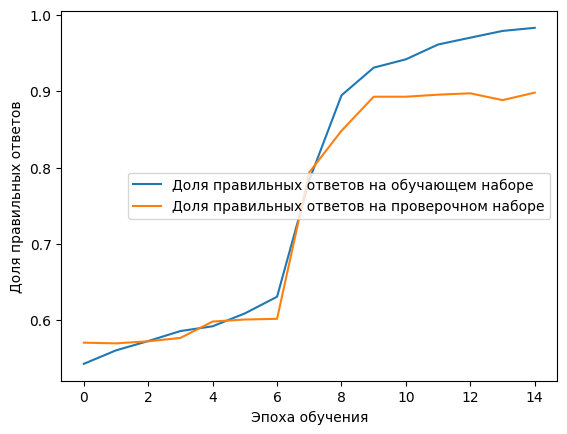

In [85]:
plt.plot(history['accuracy'],
         label='Доля правильных ответов на обучающем наборе')
plt.plot(history['val_accuracy'],
         label='Доля правильных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля правильных ответов')
plt.legend()
plt.show()

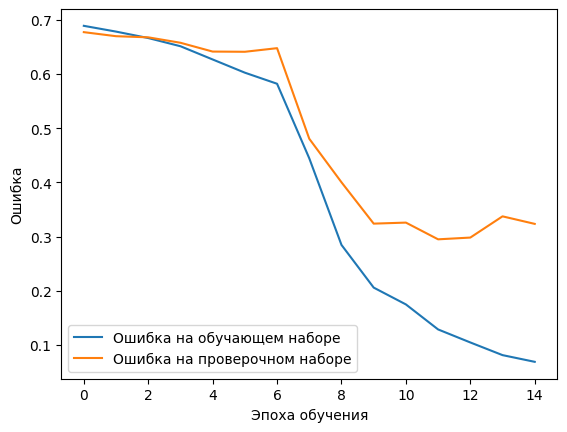

In [86]:
plt.plot(history['loss'],
         label='Ошибка на обучающем наборе')
plt.plot(history['val_loss'],
         label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

## Оцениваем качество обучения на тестовом наборе данных

Определяем долю правильных ответов (accuracy) на тестовом наборе данных

In [87]:
def evaluate(model, x, y):
    model.eval()
    loader = DataLoader(TensorDataset(x, y), batch_size=batch_size)
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)
            loss_sum += loss.item() * x_batch.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += x_batch.size(0)
    return loss_sum / total, correct / total

test_loss, test_acc = evaluate(model, x_test, y_test)
print(f'Тест: loss = {test_loss:.4f}, accuracy = {test_acc:.4f}')

Тест: loss = 0.3514, accuracy = 0.9043


## Сравнение с другими архитектурами

Теперь легко ответить, зачем нужны LSTM и GRU, если уже есть SimpleRNN: они получают
гораздо больше правильных ответов. На тестовом наборе данных получаются такие результаты (точные значения немного различаются от запуска к запуску):

| Рекуррентный слой | Параметров в слое (64 -> 64) | Доля правильных ответов на тесте |
|---|---|---|
| SimpleRNN | 8 320 | 0.5764 |
| LSTM | 33 280 | 0.8975 |
| GRU | 24 960 | 0.9136 |

LSTM и GRU почти в 3-4 раза «тяжелее» SimpleRNN, но зато решают проблему затухающих градиентов
и запоминают дальние связи в тексте. Подробнее — в ноутбуке
[`rnn_architectures_theory.ipynb`](rnn_architectures_theory.ipynb).

In [88]:
def count_parameters(layer):
    return sum(p.numel() for p in layer.parameters())

for name, layer in [('SimpleRNN', nn.RNN(64, 64, batch_first=True)),
                    ('LSTM', nn.LSTM(64, 64, batch_first=True)),
                    ('GRU', nn.GRU(64, 64, batch_first=True))]:
    n = count_parameters(layer)
    print('Параметров в слое', name, ':', n)

Параметров в слое SimpleRNN : 8320
Параметров в слое LSTM : 33280
Параметров в слое GRU : 24960


## Применяем модель для определения тональности отзыва на банк

**Позитивный отзыв**

In [89]:
positive_text = """Брал кредит в Мегабанке на автомобиль. Выдали за один день. Никаких скрытых комиссий и переплат.
У банка удобное мобильное приложение, через которое можно быстро отправить ежемесячный платеж.
Досрочное гасить начал через три месяца. Я доволен оперативностью и удобством. Огромное спасибо!
"""

In [90]:
positive_preprocessed_text = preprocess(positive_text, stop_words, punctuation_marks, morph)

In [91]:
positive_seq = text_to_sequence(positive_preprocessed_text, word_to_index)

In [92]:
positive_padded_seq = pad_sequences_post([positive_seq], maxlen)
positive_tensor = torch.from_numpy(positive_padded_seq).to(device)

**Выполняем распознавание**

In [93]:
model.eval()
with torch.no_grad():
    prob = torch.sigmoid(model(positive_tensor))
print('Вероятность положительного отзыва:', prob.item())

Вероятность положительного отзыва: 0.9868304133415222


**Негативный отзыв**

In [94]:
negative_text = """Взял кредит в ТакСебеБанке на автомобиль. В договор включили обязательный контракт
на помощь на дороге, который мне не нужен. Узнал об этом только во время подписания договора, иначе бы отказался.
Альтернативы была страхование жизни, но мне это даже не предложили. Скорее всего, менеджер продвигает
продажи услуг этой компании в ущерб интересов клиента. Как минимум, непорядочно и непрофессионально.
У банка ужасное мобильное приложение, из-за которого с меня взяли штраф 10 тыс.руб. По требованиям
банка после покупки автомобиля в приложении нужно загрузить ПТС. Я загрузил и проверил, что ПТС в приложении есть.
Но через некоторое время ПТС из приложения пропал и с меня взяли штраф. Никому не рекомендую связываться с ТакСебеБанком.
"""

In [95]:
negative_preprocessed_text = preprocess(negative_text, stop_words, punctuation_marks, morph)
negative_seq = text_to_sequence(negative_preprocessed_text, word_to_index)
negative_padded_seq = pad_sequences_post([negative_seq], maxlen)
negative_tensor = torch.from_numpy(negative_padded_seq).to(device)

In [96]:
model.eval()
with torch.no_grad():
    prob = torch.sigmoid(model(negative_tensor))
print('Вероятность отрицательного отзыва:', 1 - prob.item())
print('Вероятность положительного отзыва:', prob.item())

Вероятность отрицательного отзыва: 0.9591086320579052
Вероятность положительного отзыва: 0.0408913679420948
